# SVM — Diabetes 30-Day Readmission Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    f1_score,
    precision_score,
    recall_score,
    PrecisionRecallDisplay,
)

In [2]:
X_train_full = pd.read_csv('../Data/X_train.csv')
X_test_full  = pd.read_csv('../Data/X_test.csv')
y_train      = pd.read_csv('../Data/y_train.csv').squeeze()
y_test       = pd.read_csv('../Data/y_test.csv').squeeze()

top_features = pd.read_csv('../Data/top_features.csv', header=None).squeeze().tolist()

X_train_top = X_train_full[top_features].copy()
X_test_top  = X_test_full[top_features].copy()

print(f'All features:  {X_train_full.shape[1]}')
print(f'Top features:  {len(top_features)}')
print(f'Train samples: {X_train_full.shape[0]}  |  Test samples: {X_test_full.shape[0]}')
print(f'Positive rate: {y_train.mean():.3f}')

All features:  131
Top features:  34
Train samples: 55989  |  Test samples: 13998
Positive rate: 0.090


### Feature Selection Note

There is no feature ranking in SVM, therefore, feature selection will not be performed using it. In this notebook, I chose the top 34 features based on feature selection from random forest conducted previously in feature_importance.ipynb file.

The optimal method for feature elimination would have been Recursive Feature Elimination using weights assigned to features based on coefficients provided by SVM. However this would be too expensive, as it is a time-consuming algorithm with ~56,000 rows in the training dataset, to apply to all 131 raw features and to take into account a large number of one-hot encoding variables (which are extremely sparse and cause SVM to train very slowly).

The reason behind the above choice is that random forests assign importance scores to those features that can be beneficial for tree-based models.

## 2. Baseline SVM

Linear SVM on all 89 features, no class weighting, default 0.5 threshold. `CalibratedClassifierCV` wraps the `LinearSVC` so we get probability estimates for ROC / PR curves.

In [3]:
base_svm = LinearSVC(max_iter=10000, random_state=42, dual='auto')
base_model = CalibratedClassifierCV(base_svm, cv=5)
base_model.fit(X_train_full, y_train)

base_pred      = base_model.predict(X_test_full)
base_pred_prob = base_model.predict_proba(X_test_full)[:, 1]

print('Baseline SVM Classification Report:')
print(classification_report(y_test, base_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, base_pred_prob):.4f}')

Baseline SVM Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.91      1.00      0.95     12741
Readmitted <30       0.39      0.01      0.01      1257

      accuracy                           0.91     13998
     macro avg       0.65      0.50      0.48     13998
  weighted avg       0.86      0.91      0.87     13998

ROC-AUC: 0.6505


## 3. Tuned SVM

Top features only, `class_weight='balanced'` to up-weight the minority class (readmitted within 30 days). We then sweep decision thresholds to maximise F1 for the minority class.

In [4]:
tuned_svm = LinearSVC(class_weight='balanced', max_iter=10000, random_state=42, dual='auto')
tuned_model = CalibratedClassifierCV(tuned_svm, cv=5)
tuned_model.fit(X_train_top, y_train)

y_pred      = tuned_model.predict(X_test_top)
y_pred_prob = tuned_model.predict_proba(X_test_top)[:, 1]

print('Tuned SVM Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

Tuned SVM Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.91      1.00      0.95     12741
Readmitted <30       0.22      0.00      0.00      1257

      accuracy                           0.91     13998
     macro avg       0.57      0.50      0.48     13998
  weighted avg       0.85      0.91      0.87     13998

ROC-AUC: 0.6459


In [5]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_pred_prob >= t).astype(int), pos_label=1, zero_division=0)
              for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)
print(f'Best threshold: {best_thresh:.2f}  |  Best minority F1: {best_f1:.3f}')

Best threshold: 0.11  |  Best minority F1: 0.224


In [6]:
y_pred_best = (y_pred_prob >= best_thresh).astype(int)

print(f'Tuned SVM at threshold = {best_thresh:.2f}:')
print(classification_report(y_test, y_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))

Tuned SVM at threshold = 0.11:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.81      0.87     12741
Readmitted <30       0.16      0.36      0.22      1257

      accuracy                           0.77     13998
     macro avg       0.55      0.59      0.55     13998
  weighted avg       0.86      0.77      0.81     13998



## 4. SMOTE SVM

SMOTE oversamples the minority class in the training set by synthesising new points between existing minority neighbours. The test set stays untouched. Since the training data is now balanced, `class_weight` is no longer needed.

In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_top, y_train)

print('Class counts BEFORE SMOTE (training set):')
before = pd.Series(y_train).value_counts().rename({0: 'Not Readmitted', 1: 'Readmitted <30'})
print(before.to_string())

print('\nClass counts AFTER SMOTE (training set):')
after = pd.Series(y_train_smote).value_counts().rename({0: 'Not Readmitted', 1: 'Readmitted <30'})
print(after.to_string())
print(f'\nSynthetic minority samples created: {after["Readmitted <30"] - before["Readmitted <30"]:,}')

smote_svm   = LinearSVC(max_iter=10000, random_state=42, dual='auto')
smote_model = CalibratedClassifierCV(smote_svm, cv=5)
smote_model.fit(X_train_smote, y_train_smote)

smote_pred_prob = smote_model.predict_proba(X_test_top)[:, 1]

smote_f1_scores   = [f1_score(y_test, (smote_pred_prob >= t).astype(int),
                               pos_label=1, zero_division=0) for t in thresholds]
smote_best_thresh = thresholds[np.argmax(smote_f1_scores)]
smote_pred_best   = (smote_pred_prob >= smote_best_thresh).astype(int)

print(f'\nSMOTE SVM at threshold = {smote_best_thresh:.2f}:')
print(classification_report(y_test, smote_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, smote_pred_prob):.4f}')

Class counts BEFORE SMOTE (training set):
readmitted
Not Readmitted    50961
Readmitted <30     5028

Class counts AFTER SMOTE (training set):
readmitted
Not Readmitted    50961
Readmitted <30    50961

Synthetic minority samples created: 45,933

SMOTE SVM at threshold = 0.53:
                precision    recall  f1-score   support

Not Readmitted       0.92      0.77      0.84     12741
Readmitted <30       0.13      0.35      0.19      1257

      accuracy                           0.73     13998
     macro avg       0.53      0.56      0.51     13998
  weighted avg       0.85      0.73      0.78     13998

ROC-AUC: 0.5718


## 4b. Interaction Features Experiment

Interaction features multiply two related features together to capture their **joint** effect. For a linear model like LinearSVC, this is the only way to represent non-linear relationships between feature pairs. We test whether adding clinically motivated interactions improves the SVM's minority-class F1.

In [8]:
interactions = {
    'inpatient_x_medications': ('number_inpatient', 'num_medications'),
    'inpatient_x_time':        ('number_inpatient', 'time_in_hospital'),
    'age_x_diagnoses':         ('age',              'number_diagnoses'),
    'age_x_inpatient':         ('age',              'number_inpatient'),
    'insulin_x_inpatient':     ('insulin',          'number_inpatient'),
}

X_train_inter = X_train_top.copy()
X_test_inter  = X_test_top.copy()

for name, (a, b) in interactions.items():
    X_train_inter[name] = X_train_inter[a] * X_train_inter[b]
    X_test_inter[name]  = X_test_inter[a]  * X_test_inter[b]

print(f'Features without interactions: {X_train_top.shape[1]}')
print(f'Features with interactions:    {X_train_inter.shape[1]}')
print(f'Added: {list(interactions.keys())}')

inter_svm   = LinearSVC(class_weight='balanced', max_iter=10000, random_state=42, dual='auto')
inter_model = CalibratedClassifierCV(inter_svm, cv=5)
inter_model.fit(X_train_inter, y_train)

inter_pred_prob = inter_model.predict_proba(X_test_inter)[:, 1]

inter_f1_scores   = [f1_score(y_test, (inter_pred_prob >= t).astype(int),
                               pos_label=1, zero_division=0) for t in thresholds]
inter_best_thresh = thresholds[np.argmax(inter_f1_scores)]
inter_best_f1     = max(inter_f1_scores)
inter_pred_best   = (inter_pred_prob >= inter_best_thresh).astype(int)

print(f'\n--- SVM WITHOUT Interactions (Tuned) ---')
print(f'Best threshold: {best_thresh:.2f}  |  Minority F1: {best_f1:.3f}')
print(f'Macro F1: {f1_score(y_test, y_pred_best, average="macro", zero_division=0):.3f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_pred_prob):.4f}')

print(f'\n--- SVM WITH Interactions ---')
print(f'Best threshold: {inter_best_thresh:.2f}  |  Minority F1: {inter_best_f1:.3f}')
print(f'Macro F1: {f1_score(y_test, inter_pred_best, average="macro", zero_division=0):.3f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, inter_pred_prob):.4f}')

diff = inter_best_f1 - best_f1
if diff > 0.005:
    print(f'\nInteraction features improved minority F1 by {diff:+.3f}')
elif diff < -0.005:
    print(f'\nInteraction features hurt minority F1 by {diff:+.3f}')
else:
    print(f'\nInteraction features had negligible effect on minority F1 ({diff:+.3f})')

Features without interactions: 34
Features with interactions:    39
Added: ['inpatient_x_medications', 'inpatient_x_time', 'age_x_diagnoses', 'age_x_inpatient', 'insulin_x_inpatient']

--- SVM WITHOUT Interactions (Tuned) ---
Best threshold: 0.11  |  Minority F1: 0.224
Macro F1: 0.546
ROC-AUC:  0.6459

--- SVM WITH Interactions ---
Best threshold: 0.11  |  Minority F1: 0.227
Macro F1: 0.546
ROC-AUC:  0.6460

Interaction features had negligible effect on minority F1 (+0.002)


## 4c. RBF Kernel SVM with Hyperparameter Tuning

A linear SVM can only draw a flat decision boundary. An **RBF (radial basis function)** kernel maps the data into a higher-dimensional space where a non-linear boundary becomes possible — this can capture complex patterns that linear models miss.

We tune two hyperparameters via grid search:
- **C** — regularisation strength. Higher C = stricter fit to training data.
- **gamma** — how far the influence of a single training point reaches. Higher gamma = tighter, more localised decision regions.

Because RBF SVM is O(n²)–O(n³), we run the grid search on a 10k stratified subsample, then retrain the best configuration on the full training set.

In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit

# --- Step 1: Subsample for grid search (RBF is slow on 55k rows) ---
sub_idx = StratifiedShuffleSplit(n_splits=1, train_size=20000, random_state=42)
sub_train, _ = next(sub_idx.split(X_train_top, y_train))

X_sub = X_train_top.iloc[sub_train]
y_sub = y_train.iloc[sub_train]
print(f'Grid search subsample: {X_sub.shape[0]} rows  |  positive rate: {y_sub.mean():.3f}')

# --- Step 2: Grid search over C and gamma ---
param_grid = {
    'C':     [0.1, 1, 10, 50],
    'gamma': ['scale', 0.01, 0.05, 0.1],
}

grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_sub, y_sub)

print(f'\nBest params: {grid.best_params_}')
print(f'Best CV F1:  {grid.best_score_:.3f}')

Grid search subsample: 20000 rows  |  positive rate: 0.090
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best params: {'C': 1, 'gamma': 0.01}
Best CV F1:  0.222


In [10]:
# --- Step 3: Retrain best RBF SVM on full training data ---
rbf_svm = SVC(
    kernel='rbf',
    C=grid.best_params_['C'],
    gamma=grid.best_params_['gamma'],
    class_weight='balanced',
    probability=True,
    random_state=42,
)
rbf_svm.fit(X_train_top, y_train)

rbf_pred_prob = rbf_svm.predict_proba(X_test_top)[:, 1]

rbf_f1_scores   = [f1_score(y_test, (rbf_pred_prob >= t).astype(int),
                             pos_label=1, zero_division=0) for t in thresholds]
rbf_best_thresh = thresholds[np.argmax(rbf_f1_scores)]
rbf_best_f1     = max(rbf_f1_scores)
rbf_pred_best   = (rbf_pred_prob >= rbf_best_thresh).astype(int)

print(f'RBF SVM at threshold = {rbf_best_thresh:.2f}:')
print(classification_report(y_test, rbf_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, rbf_pred_prob):.4f}')

print(f'\n--- Comparison: Linear vs RBF ---')
print(f'Linear Tuned  -> F1: {best_f1:.3f}  |  ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'RBF Tuned     -> F1: {rbf_best_f1:.3f}  |  ROC-AUC: {roc_auc_score(y_test, rbf_pred_prob):.4f}')

RBF SVM at threshold = 0.13:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.82      0.87     12741
Readmitted <30       0.17      0.37      0.23      1257

      accuracy                           0.78     13998
     macro avg       0.55      0.60      0.55     13998
  weighted avg       0.86      0.78      0.81     13998

ROC-AUC: 0.6443

--- Comparison: Linear vs RBF ---
Linear Tuned  -> F1: 0.224  |  ROC-AUC: 0.6459
RBF Tuned     -> F1: 0.234  |  ROC-AUC: 0.6443


## 5. Model Comparison

In [11]:
results = {
    'Model':                ['Baseline', 'Tuned', 'SMOTE', 'RBF Tuned'],
    'Features':             [X_train_full.shape[1], len(top_features), len(top_features), len(top_features)],
    'Imbalance handling':   ['None', 'class_weight=balanced', 'SMOTE oversampling', 'class_weight=balanced'],
    'Threshold':            [0.50, round(best_thresh, 2), round(smote_best_thresh, 2), round(rbf_best_thresh, 2)],
    'Precision (minority)': [
        round(precision_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, rbf_pred_best,   pos_label=1, zero_division=0), 3),
    ],
    'Recall (minority)': [
        round(recall_score(y_test, base_pred),       3),
        round(recall_score(y_test, y_pred_best),     3),
        round(recall_score(y_test, smote_pred_best), 3),
        round(recall_score(y_test, rbf_pred_best),   3),
    ],
    'F1 (minority)': [
        round(f1_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, rbf_pred_best,   pos_label=1, zero_division=0), 3),
    ],
    'Macro F1': [
        round(f1_score(y_test, base_pred,       average='macro', zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     average='macro', zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, average='macro', zero_division=0), 3),
        round(f1_score(y_test, rbf_pred_best,   average='macro', zero_division=0), 3),
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, base_pred_prob),  4),
        round(roc_auc_score(y_test, y_pred_prob),     4),
        round(roc_auc_score(y_test, smote_pred_prob), 4),
        round(roc_auc_score(y_test, rbf_pred_prob),   4),
    ],
}

pd.DataFrame(results)

,Model,Features,Imbalance handling,Threshold,Precision (minority),Recall (minority),F1 (minority),Macro F1,ROC-AUC
0,Baseline,131,None,0.50,0.391,0.007,0.014,0.483,0.6505
1,Tuned,34,class_weight=balanced,0.11,0.162,0.364,0.224,0.546,0.6459
2,SMOTE,34,SMOTE oversampling,0.53,0.131,0.355,0.191,0.515,0.5718
3,RBF Tuned,34,class_weight=balanced,0.13,0.170,0.375,0.234,0.552,0.6443


## 6. Confusion Matrices

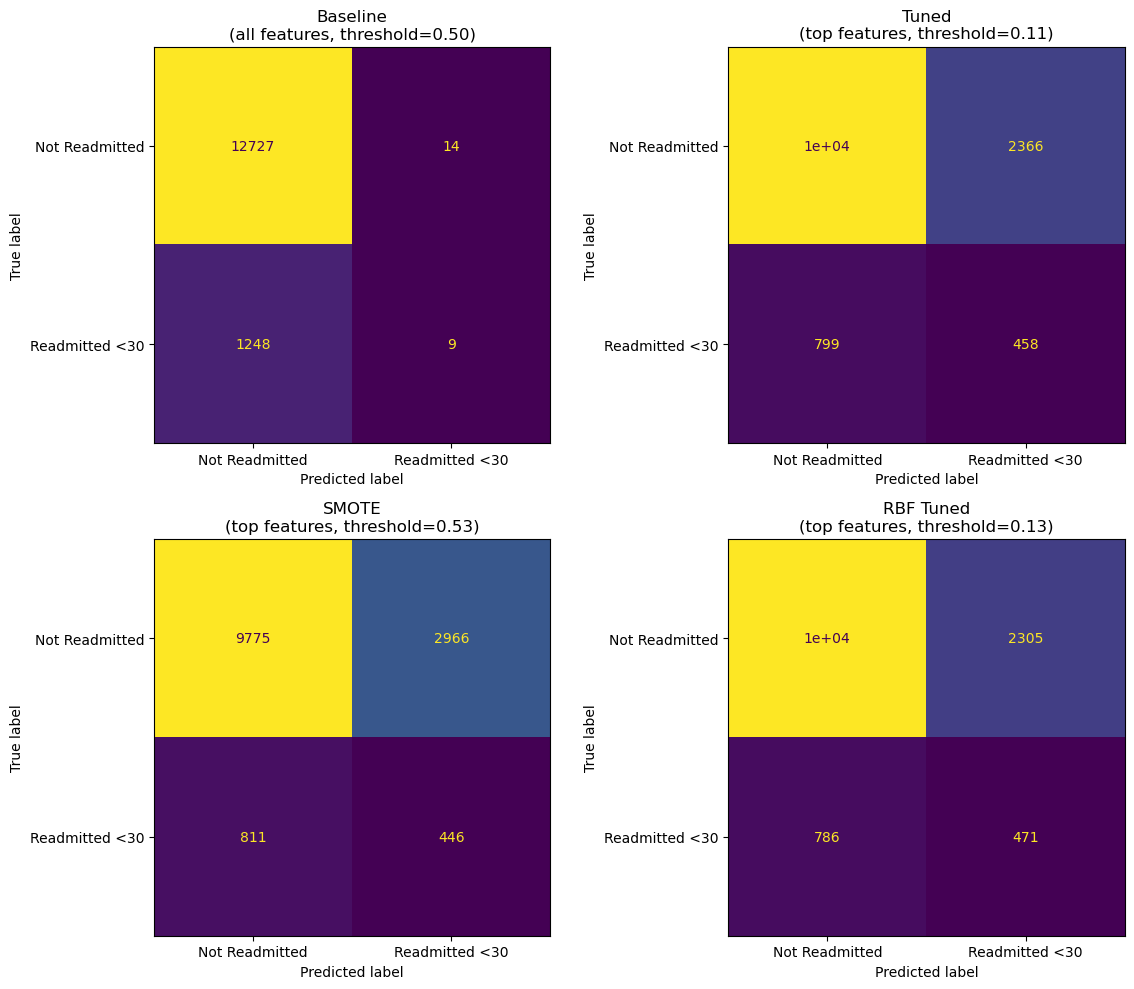

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, base_pred),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title('Baseline\n(all features, threshold=0.50)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title(f'Tuned\n(top features, threshold={best_thresh:.2f})')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, smote_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'SMOTE\n(top features, threshold={smote_best_thresh:.2f})')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, rbf_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f'RBF Tuned\n(top features, threshold={rbf_best_thresh:.2f})')

plt.tight_layout()
plt.savefig('../Results/SVM_Results/confusion_matrix_svm.png', dpi=150)
plt.show()

## 7. ROC Curve & Precision-Recall Curve

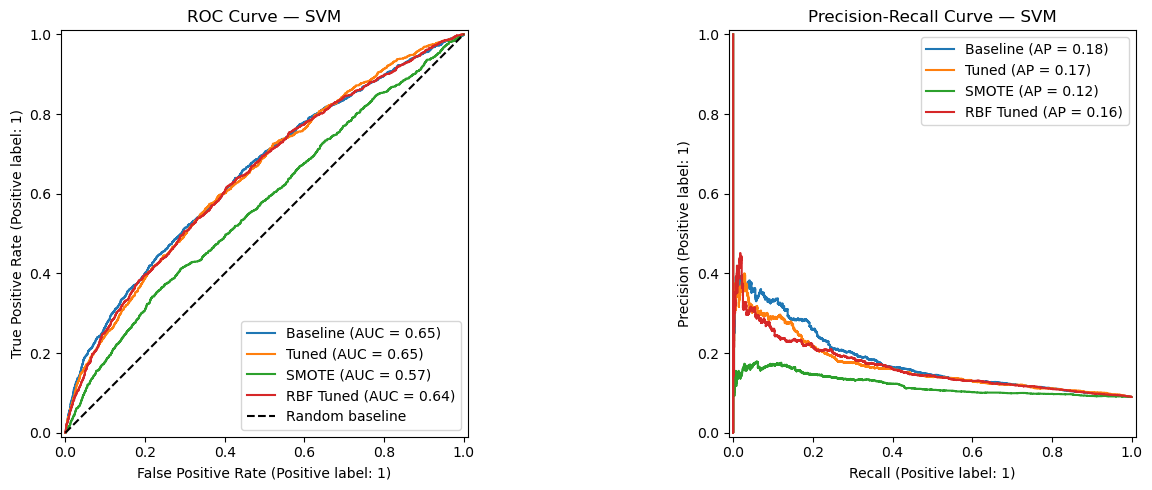

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[0], name='Tuned')
RocCurveDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[0], name='SMOTE')
RocCurveDisplay.from_predictions(y_test, rbf_pred_prob,   ax=axes[0], name='RBF Tuned')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[0].set_title('ROC Curve — SVM')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[1], name='Tuned')
PrecisionRecallDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[1], name='SMOTE')
PrecisionRecallDisplay.from_predictions(y_test, rbf_pred_prob,   ax=axes[1], name='RBF Tuned')
axes[1].set_title('Precision-Recall Curve — SVM')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Results/SVM_Results/roc_pr_curves_svm.png', dpi=150)
plt.show()

## 8. SVM Feature Importance (Linear Coefficients)

For a linear SVM the learned weight vector has the same interpretation as logistic-regression coefficients: larger absolute values mean the feature has more influence on the decision boundary.

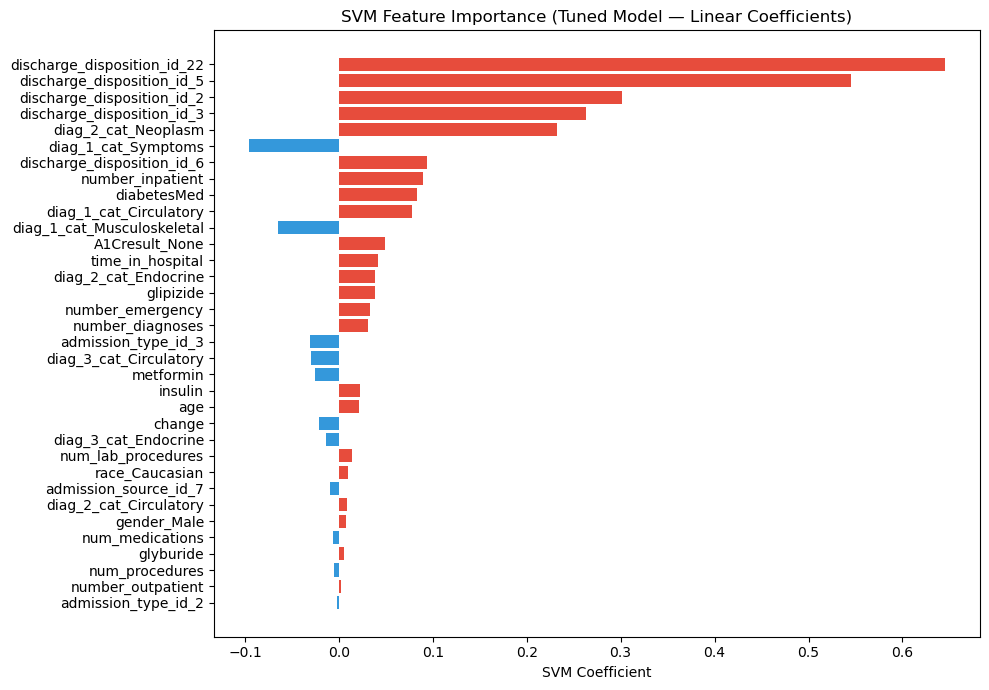

In [14]:
coef_svm = LinearSVC(class_weight='balanced', max_iter=10000, random_state=42, dual='auto')
coef_svm.fit(X_train_top, y_train)

coef_df = pd.DataFrame({
    'feature':     top_features,
    'coefficient': coef_svm.coef_[0],
})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.set_xlabel('SVM Coefficient')
ax.set_title('SVM Feature Importance (Tuned Model — Linear Coefficients)')

plt.tight_layout()
plt.savefig('../Results/SVM_Results/svm_coefficients.png', dpi=150)
plt.show()

## 9. F1 Score vs Decision Threshold

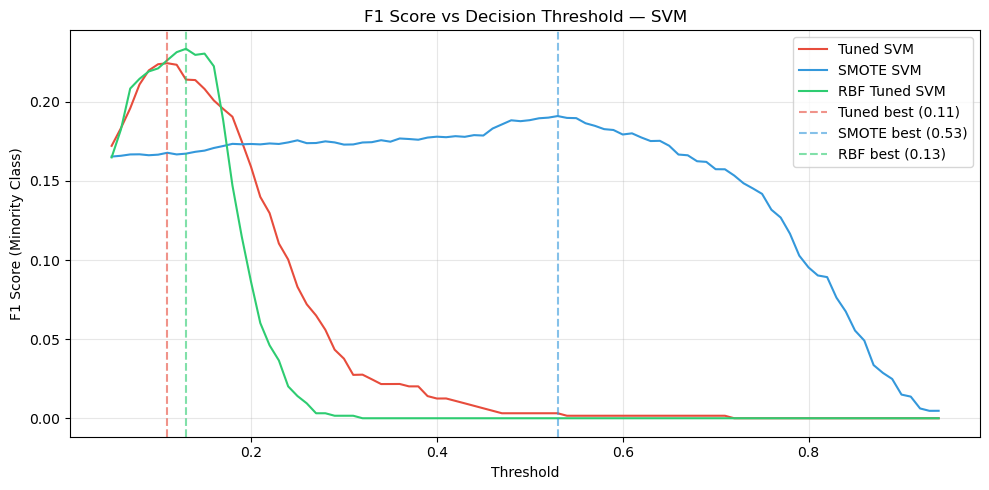

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, f1_scores,       label='Tuned SVM', color='#e74c3c')
ax.plot(thresholds, smote_f1_scores, label='SMOTE SVM', color='#3498db')
ax.plot(thresholds, rbf_f1_scores,   label='RBF Tuned SVM', color='#2ecc71')
ax.axvline(best_thresh,       ls='--', color='#e74c3c', alpha=0.6,
           label=f'Tuned best ({best_thresh:.2f})')
ax.axvline(smote_best_thresh, ls='--', color='#3498db', alpha=0.6,
           label=f'SMOTE best ({smote_best_thresh:.2f})')
ax.axvline(rbf_best_thresh,   ls='--', color='#2ecc71', alpha=0.6,
           label=f'RBF best ({rbf_best_thresh:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score (Minority Class)')
ax.set_title('F1 Score vs Decision Threshold — SVM')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/SVM_Results/f1_threshold_svm.png', dpi=150)
plt.show()